In [18]:
import os
import glob
import netCDF4
import numpy as np
import pandas as pd
import xarray as xr

import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib import gridspec
import cartopy.crs as ccrs
import cartopy.feature
import seaborn as sns

import wrf
from cartopy.mpl.gridliner import LATITUDE_FORMATTER, LONGITUDE_FORMATTER
import matplotlib.ticker as mticker
import matplotlib.colors

import matplotlib as mpl

from metpy import calc as mpcalc
from scipy import stats

In [19]:
######################
# FUNCTIONS
######################

def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return array[idx]


In [20]:
######################
# CHARGE PROCESSES
print('Charging Ant hist...')

#Parameters
folder_mod = '/capstor/scratch/cscs/gsergi/OUTPUT_PGW_20220315/ANT_20220315_'
domain = 'd01'
acc_t = 1440 #minutes
ini_date_idx=0
#end_date_idx=0

###load data###
outhist_files = '/outhist/outhist_'+domain+'_*'# Load netcdf

################
#hist
wrflist_oh = []
proj = 'hist'
print('Total: ' + str(np.size(glob.glob(folder_mod+proj+outhist_files))))
for i,ncdf_oh in enumerate(np.sort(glob.glob(folder_mod+proj+outhist_files))):
        print(i, end="\r")
        wrflist_oh.append(netCDF4.Dataset(ncdf_oh))
    
# Get surface variables
t2_ant_hist = wrf.getvar(wrflist_oh, 'T2', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:] - 273.15

# Extract the pressure, geopotential height, and wind variables
Ppertubation_ant_hist = wrf.getvar(wrflist_oh, 'P', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PB_ant_hist = wrf.getvar(wrflist_oh, 'PB', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
P_ant_hist = (Ppertubation_ant_hist + PB_ant_hist)

PHperturbation_ant_hist = wrf.getvar(wrflist_oh, 'PH', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PHB_ant_hist = wrf.getvar(wrflist_oh, 'PHB', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
Z_ant_hist = (PHperturbation_ant_hist + PHB_ant_hist)/9.8
Z_ant_hist_unstg = wrf.destagger(Z_ant_hist, stagger_dim=1)
Z_ant_hist_stg = np.diff(Z_ant_hist, axis=1)

#P_HYD_ant_hist = wrf.getvar(wrflist_oh, 'P_HYD', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
Q_ant_hist = wrf.getvar(wrflist_oh, 'QVAPOR', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PT_ant_hist = wrf.getvar(wrflist_oh, 'T', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:] + 270
T_ant_hist = PT_ant_hist * (P_ant_hist/100000)**0.286
U_ant_hist = wrf.getvar(wrflist_oh, 'U', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
V_ant_hist = wrf.getvar(wrflist_oh, 'V', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
W_ant_hist = wrf.getvar(wrflist_oh, 'W', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
U_ant_hist_unstg = wrf.destagger(U_ant_hist, stagger_dim=3)
V_ant_hist_unstg = wrf.destagger(V_ant_hist, stagger_dim=2)
W_ant_hist_unstg = wrf.destagger(W_ant_hist, stagger_dim=1)

#Calculate variables in pressure levels
g = 9.81 #m/s2
rgas = 287.058 # J/(kg-K) => m2/(s2 K)

P_sig_hist = P_ant_hist[:,:26,:,:]
Z_sig_hist = Z_ant_hist_unstg[:,:26,:,:]
Q_sig_hist = Q_ant_hist[:,:26,:,:]
T_sig_hist = T_ant_hist[:,:26,:,:]
PT_sig_hist = PT_ant_hist[:,:26,:,:]
U_sig_hist = U_ant_hist_unstg[:,:26,:,:]
V_sig_hist = V_ant_hist_unstg[:,:26,:,:]
W_sig_hist = W_ant_hist_unstg[:,:26,:,:]
Rho_sig_hist  = P_sig_hist/(rgas*T_sig_hist)
Omega_sig_hist = - W_sig_hist * Rho_sig_hist * g



################
#past
wrflist_oh = []
proj = 'past_new'
print('Total: ' + str(np.size(glob.glob(folder_mod+proj+outhist_files))))
for i,ncdf_oh in enumerate(np.sort(glob.glob(folder_mod+proj+outhist_files))):
        print(i, end="\r")
        wrflist_oh.append(netCDF4.Dataset(ncdf_oh))
    
# Get surface variables
t2_ant_hist = wrf.getvar(wrflist_oh, 'T2', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:] - 273.15

# Extract the pressure, geopotential height, and wind variables
Ppertubation_ant_past = wrf.getvar(wrflist_oh, 'P', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PB_ant_past = wrf.getvar(wrflist_oh, 'PB', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
P_ant_past = (Ppertubation_ant_past + PB_ant_past)

PHperturbation_ant_past = wrf.getvar(wrflist_oh, 'PH', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PHB_ant_past = wrf.getvar(wrflist_oh, 'PHB', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
Z_ant_past = (PHperturbation_ant_past + PHB_ant_past)/9.8
Z_ant_past_unstg = wrf.destagger(Z_ant_past, stagger_dim=1)
Z_ant_past_stg = np.diff(Z_ant_past, axis=1)

#P_HYD_ant_hist = wrf.getvar(wrflist_oh, 'P_HYD', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
Q_ant_past = wrf.getvar(wrflist_oh, 'QVAPOR', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
PT_ant_past = wrf.getvar(wrflist_oh, 'T', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:] + 270
T_ant_past = PT_ant_past * (P_ant_past/100000)**0.286
U_ant_past = wrf.getvar(wrflist_oh, 'U', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
V_ant_past = wrf.getvar(wrflist_oh, 'V', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
W_ant_past = wrf.getvar(wrflist_oh, 'W', timeidx=wrf.ALL_TIMES)[ini_date_idx:,:,:,:]
U_ant_past_unstg = wrf.destagger(U_ant_past, stagger_dim=3)
V_ant_past_unstg = wrf.destagger(V_ant_past, stagger_dim=2)
W_ant_past_unstg = wrf.destagger(W_ant_past, stagger_dim=1)

#Calculate variables in pressure levels
g = 9.81 #m/s2
rgas = 287.058 # J/(kg-K) => m2/(s2 K)

P_sig_past = P_ant_past[:,:26,:,:]
Z_sig_past = Z_ant_past_unstg[:,:26,:,:]
Q_sig_past = Q_ant_past[:,:26,:,:]
T_sig_past = T_ant_past[:,:26,:,:]
PT_sig_past = PT_ant_past[:,:26,:,:]
U_sig_past = U_ant_past_unstg[:,:26,:,:]
V_sig_past = V_ant_past_unstg[:,:26,:,:]
W_sig_past = W_ant_past_unstg[:,:26,:,:]
Rho_sig_past  = P_sig_past/(rgas*T_sig_past)
Omega_sig_past = - W_sig_past * Rho_sig_past * g

    
######################
# ANT COORDINATES
# Get surface fix variables
height = wrf.getvar(wrflist_oh, 'HGT', timeidx=0, method="cat")[:,:]
# Get dimension
lats, lons = wrf.latlon_coords(t2_ant_hist)
x, y = wrf.ll_to_xy(wrflist_oh, lons, lats)
times = wrf.extract_times(wrflist_oh, timeidx=wrf.ALL_TIMES)

Charging Ant hist...
Total: 59
Total: 59


/users/gsergi/miniconda3/lib/python3.9/site-packages/wrf/latlonutils.py:434: RuntimeWarning: invalid value encountered in cast
  result = np.rint(result).astype(int)


In [21]:
########################################
#Calculate Heat Tendency Equation components (level simga = 2)
#######################################
Xdist = Ydist = 27000

#Levels to average
lev_bottom = 1
lev_top = 4

#Create weighting by elevation of each layer
Z_ant_weighting = np.empty_like(Z_ant_hist_stg[:,lev_bottom:lev_top, :, :])
for i in range(lev_top-lev_bottom):
    Z_ant_weighting[:,i,:,:] = Z_ant_hist_stg[:,lev_bottom + i, :, :] / Z_ant_hist_stg[:,lev_bottom:lev_top, :, :].sum(axis=1)

#########
# hist
#Advection in horizontal axis
dT_dx = (np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dT_dy = (np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
Adv_hist = - (np.sum(U_sig_hist[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dx[:,1:-1,:] + np.sum(V_sig_hist[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dy[:,:,1:-1]) *86400/24 #units deg/hour
Adv_hist = Adv_hist[1:-1,:,:]

#Advection in vertical axis
dT_dz = ((T_sig_hist[:,lev_bottom-1,:,:] - T_sig_hist[:,lev_top+1,:,:]) / (Z_sig_hist[:,lev_bottom-1,:,:]-Z_sig_hist[:,lev_top+1,:,:]))
VAdv_hist = - (np.sum(W_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dT_dz[:,:,:]) *86400/24 #units deg/hour
VAdv_hist = VAdv_hist[1:-1,1:-1,1:-1]

#Temperature Tendency
T_hist_sec = np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)[:-1,1:-1,1:-1]
Tend_hist = (T_hist_sec[1:,:,:].values - T_hist_sec[:-1,:,:].values) /3 #units deg/hour

#Temperature Tendency
Res_hist = Tend_hist[:,:,:]- Adv_hist - VAdv_hist

#Temperature
T_hist = np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)



#########
# past
#Advection in horizontal axis
dT_dx = (np.diff(np.sum(T_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(T_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dT_dy = (np.diff(np.sum(T_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(T_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
Adv_past = - (np.sum(U_sig_past[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dx[:,1:-1,:] + np.sum(V_sig_past[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dT_dy[:,:,1:-1]) *86400/24 #units deg/hour
Adv_past = Adv_past[1:-1,:,:]

#Advection in vertical axis
dT_dz = ((T_sig_past[:,lev_bottom-1,:,:] - T_sig_past[:,lev_top+1,:,:]) / (Z_sig_past[:,lev_bottom-1,:,:]-Z_sig_past[:,lev_top+1,:,:]))
VAdv_past = - (np.sum(W_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dT_dz[:,:,:]) *86400/24 #units deg/hour
VAdv_past = VAdv_past[1:-1,1:-1,1:-1]

#Temperature Tendency
T_past_sec = np.sum(T_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)[:-1,1:-1,1:-1]
Tend_past = (T_past_sec[1:,:,:].values - T_past_sec[:-1,:,:].values) /3 #units deg/hour

#Temperature Tendency
Res_past = Tend_past - Adv_past - VAdv_past

#Temperature
T_past= np.sum(T_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1)

In [22]:
########################################
#Calculate Moisture Tendency Equation components (level simga = 2)
#######################################
Xdist = Ydist = 27000

#Levels to average
lev_bottom = 1
lev_top = 4

#########
# hist
#Advection in horizontal axis
dQ_dx = (np.diff(np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dQ_dy = (np.diff(np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
AdvQ_hist = - (np.sum(U_sig_hist[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dQ_dx[:,1:-1,:] + np.sum(V_sig_hist[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dQ_dy[:,:,1:-1]) *86400/24 #units kg/kg/hour
AdvQ_hist = AdvQ_hist[1:-1,:,:]

#Advection in vertical axis
dQ_dz = ((Q_sig_hist[:,lev_bottom-1,:,:]*1000 - Q_sig_hist[:,lev_top+1,:,:]*1000) / (Z_sig_hist[:,lev_bottom-1,:,:]-Z_sig_hist[:,lev_top+1,:,:]))
VAdvQ_hist = - (np.sum(W_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dQ_dz[:,:,:]) *86400/24 #units kg/kg/hour
VAdvQ_hist = VAdvQ_hist[1:-1,1:-1,1:-1]

#Moisture Tendency
Q_hist_sec = np.sum(Q_sig_hist[:-1,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:-1,:,1:-1,1:-1], axis=1)*1000
TendQ_hist = (Q_hist_sec[1:,:,:].values - Q_hist_sec[:-1,:,:].values) /3 #units kg/kg/hour

#Temperature Tendency
ResQ_hist = TendQ_hist - AdvQ_hist - VAdvQ_hist

# Moisture
Q_hist = np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1)


#########
# past
dQ_dx = (np.diff(np.sum(Q_sig_past[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=2)[:,:,:-1] + np.diff(np.sum(Q_sig_past[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=2)[:,:,1:]) / (Xdist)
dQ_dy = (np.diff(np.sum(Q_sig_past[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=1)[:,:-1,:] + np.diff(np.sum(Q_sig_past[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1), axis=1)[:,1:,:]) / (Ydist)
AdvQ_past = - (np.sum(U_sig_past[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dQ_dx[:,1:-1,:] + np.sum(V_sig_past[:,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:,:,1:-1,1:-1], axis=1)*dQ_dy[:,:,1:-1]) *86400/24 #units kg/kg/hour
AdvQ_past = AdvQ_past[1:-1,:,:]

#Advection in vertical axis
dQ_dz = ((Q_sig_past[:,lev_bottom-1,:,:]*1000 - Q_sig_past[:,lev_top+1,:,:]*1000) / (Z_sig_past[:,lev_bottom-1,:,:]-Z_sig_past[:,lev_top+1,:,:]))
VAdvQ_past = - (np.sum(W_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_weighting, axis=1) * dQ_dz[:,:,:]) *86400/24 #units kg/kg/hour
VAdvQ_past = VAdvQ_past[1:-1,1:-1,1:-1]

#Moisture Tendency
Q_past_sec = np.sum(Q_sig_past[:-1,lev_bottom:lev_top,1:-1,1:-1]*Z_ant_weighting[:-1,:,1:-1,1:-1], axis=1)*1000
TendQ_past = (Q_past_sec[1:,:,:].values - Q_past_sec[:-1,:,:].values) /3 #units kg/kg/hour

#Temperature Tendency
ResQ_past = TendQ_past- AdvQ_past - VAdvQ_past

#Moisture
Q_past = np.sum(Q_sig_past[:,lev_bottom:lev_top,:,:]*1000*Z_ant_weighting, axis=1)

In [23]:
########################################
#Calculate Moisture Convergence (level simga = 2)
#######################################

#########
# hist
#Moisture convergence in horizontal axis
dMC_dx = (np.diff(Q_sig_hist[:,:,:,:]*1000*U_sig_hist[:,:,:,:], axis=3)[:,:,:,:-1] + np.diff(Q_sig_hist[:,:,:,:]*1000*U_sig_hist[:,:,:,:], axis=3)[:,:,:,1:]) / (Xdist)
dMC_dy = (np.diff(Q_sig_hist[:,:,:,:]*1000*V_sig_hist[:,:,:,:], axis=2)[:,:,:-1,:] + np.diff(Q_sig_hist[:,:,:,:]*1000*V_sig_hist[:,:,:,:], axis=2)[:,:,1:,:]) / (Ydist)
MC_hist = - (dMC_dx[:,:,1:-1,:] + dMC_dy[:,:,:,1:-1])*Rho_sig_hist[:,:,1:-1,1:-1]*Z_ant_hist_stg[:,:26,1:-1,1:-1]  #kg m-2 s-1

#VIMC (Vertically integrated moisture convergence)
Qx = 1/9.81 * np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*U_sig_hist[:,lev_bottom:lev_top,:,:]*Rho_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_hist_stg[:,lev_bottom:lev_top,:,:], axis=1)
Qy = 1/9.81 * np.sum(Q_sig_hist[:,lev_bottom:lev_top,:,:]*1000*V_sig_hist[:,lev_bottom:lev_top,:,:]*Rho_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_hist_stg[:,lev_bottom:lev_top,:,:], axis=1)
dQ_dx = (np.diff(Qx, axis=2)[:,:,:-1] + np.diff(Qx, axis=2)[:,:,1:]) / (Xdist)
dQ_dy = (np.diff(Qy, axis=1)[:,:-1,:] + np.diff(Qy, axis=1)[:,1:,:]) / (Ydist)
VIMC_hist = - (dQ_dx[:,1:-1,:] + dQ_dy[:,:,1:-1]) #kg m-2 s-1

#VITC (Vertically integrated temperature convergence)
Tx = 1/9.81 * np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*1000*U_sig_hist[:,lev_bottom:lev_top,:,:]*Rho_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_hist_stg[:,lev_bottom:lev_top,:,:], axis=1)
Ty = 1/9.81 * np.sum(T_sig_hist[:,lev_bottom:lev_top,:,:]*1000*V_sig_hist[:,lev_bottom:lev_top,:,:]*Rho_sig_hist[:,lev_bottom:lev_top,:,:]*Z_ant_hist_stg[:,lev_bottom:lev_top,:,:], axis=1)
dTx_dx = (np.diff(Tx, axis=2)[:,:,:-1] + np.diff(Tx, axis=2)[:,:,1:]) / (Xdist)
dTy_dy = (np.diff(Ty, axis=1)[:,:-1,:] + np.diff(Ty, axis=1)[:,1:,:]) / (Ydist)
VITC_hist = - (dTx_dx[:,1:-1,:] + dTy_dy[:,:,1:-1]) #K s-1

#########
# past
#Advection in horizontal axis
dMC_dx = (np.diff(Q_sig_past[:,:,:,:]*1000*U_sig_past[:,:,:,:], axis=3)[:,:,:,:-1] + np.diff(Q_sig_past[:,:,:,:]*1000*U_sig_past[:,:,:,:], axis=3)[:,:,:,1:]) / (Xdist)
dMC_dy = (np.diff(Q_sig_past[:,:,:,:]*1000*V_sig_past[:,:,:,:], axis=2)[:,:,:-1,:] + np.diff(Q_sig_past[:,:,:,:]*1000*V_sig_past[:,:,:,:], axis=2)[:,:,1:,:]) / (Ydist)
MC_past = - (dMC_dx[:,:,1:-1,:] + dMC_dy[:,:,:,1:-1])*Rho_sig_past[:,:,1:-1,1:-1]*Z_ant_past_stg[:,:26,1:-1,1:-1]  #kg m-2 s-1

#VIMC (Vertically integrated moisture convergence)
Qx = 1/9.81 * np.sum(Q_sig_past[:,lev_bottom:lev_top,:,:]*1000*U_sig_past[:,lev_bottom:lev_top,:,:]*Rho_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_past_stg[:,lev_bottom:lev_top,:,:], axis=1)
Qy = 1/9.81 * np.sum(Q_sig_past[:,lev_bottom:lev_top,:,:]*1000*V_sig_past[:,lev_bottom:lev_top,:,:]*Rho_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_past_stg[:,lev_bottom:lev_top,:,:], axis=1)
dQ_dx = (np.diff(Qx, axis=2)[:,:,:-1] + np.diff(Qx, axis=2)[:,:,1:]) / (Xdist)
dQ_dy = (np.diff(Qy, axis=1)[:,:-1,:] + np.diff(Qy, axis=1)[:,1:,:]) / (Ydist)
VIMC_past = - (dQ_dx[:,1:-1,:] + dQ_dy[:,:,1:-1]) #kg m-2 s-1

#VITC (Vertically integrated temperature convergence)
Tx = 1/9.81 * np.sum(T_sig_past[:,lev_bottom:lev_top,:,:]*1000*U_sig_past[:,lev_bottom:lev_top,:,:]*Rho_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_past_stg[:,lev_bottom:lev_top,:,:], axis=1)
Ty = 1/9.81 * np.sum(T_sig_past[:,lev_bottom:lev_top,:,:]*1000*V_sig_past[:,lev_bottom:lev_top,:,:]*Rho_sig_past[:,lev_bottom:lev_top,:,:]*Z_ant_past_stg[:,lev_bottom:lev_top,:,:], axis=1)
dTx_dx = (np.diff(Tx, axis=2)[:,:,:-1] + np.diff(Tx, axis=2)[:,:,1:]) / (Xdist)
dTy_dy = (np.diff(Ty, axis=1)[:,:-1,:] + np.diff(Ty, axis=1)[:,1:,:]) / (Ydist)
VITC_past = - (dTx_dx[:,1:-1,:] + dTy_dy[:,:,1:-1]) #K s-1

In [24]:
#Positions
CON_xy = wrf.ll_to_xy(wrflist_oh, -75.09978, 123.332196) #Concordia
CON_ll = wrf.xy_to_ll(wrflist_oh, CON_xy[0], CON_xy[1])
DDU_xy = wrf.ll_to_xy(wrflist_oh, -66.662778, 140.001111) #DDU
DDU_ll = wrf.xy_to_ll(wrflist_oh, DDU_xy[0], DDU_xy[1])
CIS_xy = wrf.ll_to_xy(wrflist_oh, -66.033333, 103.55) #DDU
CIS_ll = wrf.xy_to_ll(wrflist_oh, CIS_xy[0], CIS_xy[1])

In [25]:
#Get values only for the area inside the mask (Dome C area)
mask = np.load("/users/gsergi/Jupyter_notebooks/PGW_ANT_20220315/mask_DomeC.npy")
mask3d = np.broadcast_to(mask[1:-1,1:-1], Adv_hist.shape)

Adv_hist_msk = np.ma.array(Adv_hist, mask=mask3d)
VAdv_hist_msk = np.ma.array(VAdv_hist, mask=mask3d)
Tend_hist_msk = np.ma.array(Tend_hist, mask=mask3d)
Res_hist_msk = np.ma.array(Res_hist, mask=mask3d)
AdvQ_hist_msk = np.ma.array(AdvQ_hist, mask=mask3d)
VAdvQ_hist_msk = np.ma.array(VAdvQ_hist, mask=mask3d)
TendQ_hist_msk = np.ma.array(TendQ_hist, mask=mask3d)
ResQ_hist_msk = np.ma.array(ResQ_hist, mask=mask3d)
T_hist_msk = np.ma.array(T_hist[1:-1,1:-1,1:-1], mask=mask3d)
Q_hist_msk = np.ma.array(Q_hist[1:-1,1:-1,1:-1], mask=mask3d)

Adv_past_msk = np.ma.array(Adv_past, mask=mask3d)
VAdv_past_msk = np.ma.array(VAdv_past, mask=mask3d)
Tend_past_msk = np.ma.array(Tend_past, mask=mask3d)
Res_past_msk = np.ma.array(Res_past, mask=mask3d)
AdvQ_past_msk = np.ma.array(AdvQ_past, mask=mask3d)
VAdvQ_past_msk = np.ma.array(VAdvQ_past, mask=mask3d)
TendQ_past_msk = np.ma.array(TendQ_past, mask=mask3d)
ResQ_past_msk = np.ma.array(ResQ_past, mask=mask3d)
T_past_msk = np.ma.array(T_past[1:-1,1:-1,1:-1], mask=mask3d)
Q_past_msk = np.ma.array(Q_past[1:-1,1:-1,1:-1], mask=mask3d)


VIMC_hist_msk = np.ma.array(VIMC_hist[1:-1,:,:], mask=mask3d)
VITC_hist_msk = np.ma.array(VITC_hist[1:-1,:,:], mask=mask3d)
VIMC_past_msk = np.ma.array(VIMC_past[1:-1,:,:], mask=mask3d)
VITC_past_msk = np.ma.array(VITC_past[1:-1,:,:], mask=mask3d)

mask3d_MC= np.broadcast_to(mask[1:-1,1:-1], MC_hist.shape)
MC_hist_msk = np.ma.array(MC_hist, mask=mask3d_MC)
MC_past_msk = np.ma.array(MC_past, mask=mask3d_MC)


In [26]:
#Get daily values
Adv_hist_msk_D = Adv_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
VAdv_hist_msk_D = VAdv_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
Res_hist_msk_D = Res_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
Tend_hist_msk_D = Tend_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 

AdvQ_hist_msk_D = AdvQ_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
VAdvQ_hist_msk_D = VAdvQ_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
ResQ_hist_msk_D = ResQ_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
TendQ_hist_msk_D = TendQ_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 

T_hist_msk_D = T_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1)
Q_hist_msk_D = Q_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1)

Adv_past_msk_D = Adv_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1)
VAdv_past_msk_D = VAdv_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
Res_past_msk_D = Res_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
Tend_past_msk_D = Tend_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 

AdvQ_past_msk_D = AdvQ_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
VAdvQ_past_msk_D = VAdvQ_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
ResQ_past_msk_D = ResQ_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 
TendQ_past_msk_D = TendQ_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1) 

VIMC_hist_msk_D = VIMC_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1)
VITC_hist_msk_D = VITC_hist_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1)
VIMC_past_msk_D = VIMC_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1)
VITC_past_msk_D = VITC_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1)

T_past_msk_D = T_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1)
Q_past_msk_D = Q_past_msk[6:].reshape(-1, 8, 227, 227).mean(axis=1)

times_D = times[7:-6:8]

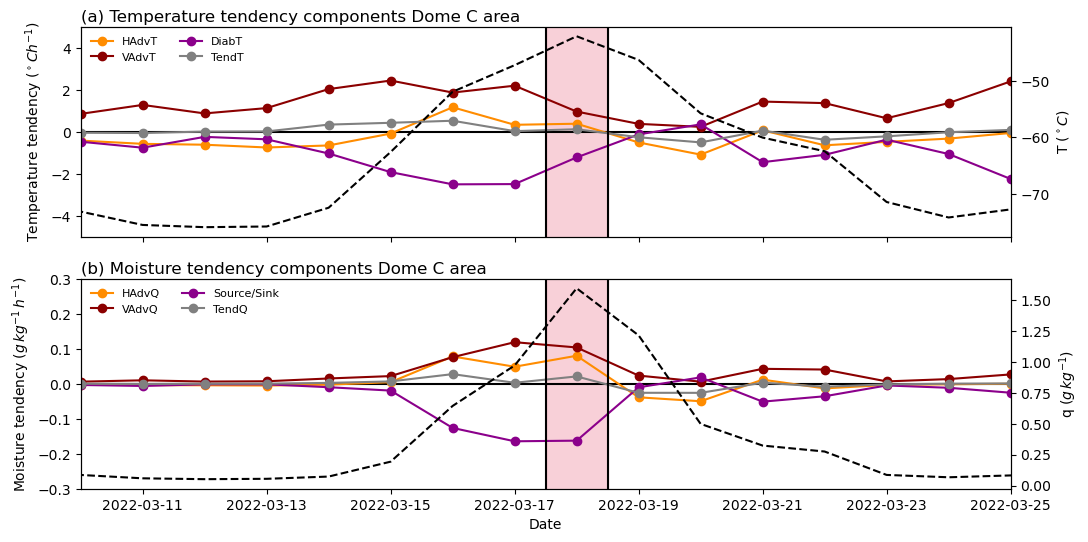

In [27]:
#############################################
# Plot Temperature and Moisture Tendency components at Concordia
#############################################

#Times Timeseries
tiniTS = np.where(times == np.datetime64('2022-03-10T00'))[0][0]
tendTS = np.where(times == np.datetime64('2022-03-25T00'))[0][0]

font = {'family' : 'normal','weight' : 'normal'}  

#Figure and axis
fig, (ax1, ax2)  = plt.subplots(2, 1, sharey=False, sharex=True, gridspec_kw={'hspace': 0.2, 'wspace':0.3}, figsize=(12,6), facecolor='white')

ax1b = ax1.twinx()
ax2b = ax2.twinx()

#Concordia Temp
ax1.plot([times[0],times[-1]],[0,0], 'k-')
ax1.plot(times_D, Adv_hist_msk_D.mean(axis=(1,2)), 'o-', c='DarkOrange', label='HAdvT')
ax1.plot(times_D, VAdv_hist_msk_D.mean(axis=(1,2)), 'o-', c='DarkRed', label='VAdvT')
ax1.plot(times_D, Res_hist_msk_D.mean(axis=(1,2)), 'o-', c='DarkMagenta', label='DiabT')
ax1.plot(times_D, Tend_hist_msk_D.mean(axis=(1,2)), 'o-', c='Gray', label='TendT')
ax1.legend(ncol=2, loc='upper left', frameon=False, fontsize=8)

ax1b.plot(times_D, T_hist_msk_D.mean(axis=(1,2))-273.15, '--', color='k', label='T')

ax1.text(0, 1.01, '(a) Temperature tendency components Dome C area', horizontalalignment='left', verticalalignment='bottom', transform=ax1.transAxes, fontsize=12)
ax1.legend(ncol=2, loc='upper left', frameon=False, fontsize=8)


#Concordia Q
ax2.plot([times[0],times[-1]],[0,0], 'k-')
ax2.plot(times_D, AdvQ_hist_msk_D.mean(axis=(1,2)), 'o-', c='DarkOrange', label='HAdvQ')
ax2.plot(times_D, VAdvQ_hist_msk_D.mean(axis=(1,2)), 'o-', c='DarkRed', label='VAdvQ')
ax2.plot(times_D, ResQ_hist_msk_D.mean(axis=(1,2)), 'o-', c='DarkMagenta', label='Source/Sink')
ax2.plot(times_D, TendQ_hist_msk_D.mean(axis=(1,2)), 'o-', c='Gray', label='TendQ')

ax2b.plot(times_D, Q_hist_msk_D.mean(axis=(1,2)), '--', color='k', label='Q')

ax2.text(0, 1.01, '(b) Moisture tendency components Dome C area', horizontalalignment='left', verticalalignment='bottom', transform=ax2.transAxes, fontsize=12)
ax2.legend(ncol=2, loc='upper left', frameon=False, fontsize=8)

#Plot parameters
ax2.set_xlabel('Date')
ax1.set_ylabel('Temperature tendency ($^\circ C h^{-1}$)')
ax2.set_ylabel('Moisture tendency ($g\, kg^{-1}\, h^{-1}$)')
ax1b.set_ylabel('T ($^\circ C$)')
ax2b.set_ylabel('q ($g\, kg^{-1}$)')
ax1.set_xlim(times[tiniTS], times[tendTS])

ax1.set_ylim(-5, 5)
ax2.set_ylim(-0.3, 0.3)
#ax2.set_ylim(-25, 0)

ax1.fill_between([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-18T12')], -10, 10, color='Crimson', alpha=0.2, zorder=0)
ax2.fill_between([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-18T12')], -10, 10, color='Crimson', alpha=0.2, zorder=0)
ax1.plot([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-17T12')],[-10,10], 'k-')
ax1.plot([np.datetime64('2022-03-18T12'),np.datetime64('2022-03-18T12')],[-10,10], 'k-')
ax2.plot([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-17T12')],[-10,10], 'k-')
ax2.plot([np.datetime64('2022-03-18T12'),np.datetime64('2022-03-18T12')],[-10,10], 'k-')

plt.savefig('Figure_Drivers_DomeC.png', dpi=300, bbox_inches = 'tight')

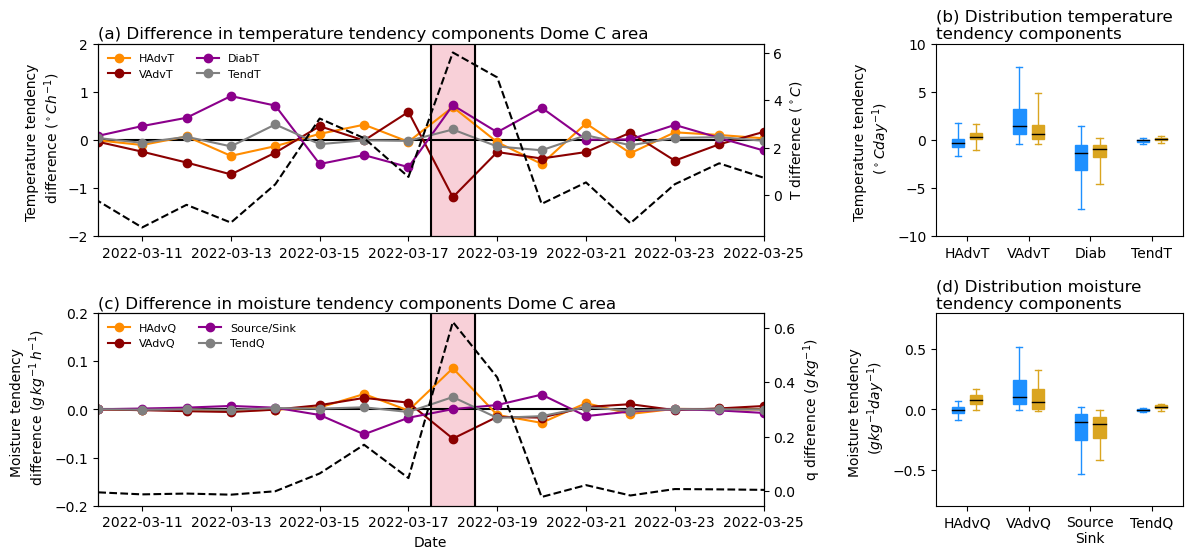

In [28]:
#############################################
# Plot Temperature and Moisture Tendency components at Concordia
#############################################

#Times Timeseries
tiniTS = np.where(times == np.datetime64('2022-03-10T00'))[0][0]
tendTS = np.where(times == np.datetime64('2022-03-25T00'))[0][0]

font = {'family' : 'normal','weight' : 'normal'}  

#Figure and axis
#Figure and axis
fig = plt.figure(figsize=[14,6])
spec = gridspec.GridSpec(ncols=3, nrows=2, figure=fig, hspace= 0.4, wspace=0.7)

### Background
ax1 = fig.add_subplot(spec[0, 0:2])
ax2 = fig.add_subplot(spec[1, 0:2])
ax3 = fig.add_subplot(spec[0, 2])
ax4 = fig.add_subplot(spec[1, 2])

ax1b = ax1.twinx()
ax2b = ax2.twinx()

#####################
# Plot Temperature Tendency components timeseries

#Concordia Temp
ax1.plot([times[0],times[-1]],[0,0], 'k-')
ax1.plot(times_D, Adv_hist_msk_D.mean(axis=(1,2)) - Adv_past_msk_D.mean(axis=(1,2)), 'o-', c='DarkOrange', label='HAdvT')
ax1.plot(times_D, VAdv_hist_msk_D.mean(axis=(1,2)) - VAdv_past_msk_D.mean(axis=(1,2)), 'o-', c='DarkRed', label='VAdvT')
ax1.plot(times_D, Res_hist_msk_D.mean(axis=(1,2)) - Res_past_msk_D.mean(axis=(1,2)), 'o-', c='DarkMagenta', label='DiabT')
ax1.plot(times_D, Tend_hist_msk_D.mean(axis=(1,2)) - Tend_past_msk_D.mean(axis=(1,2)), 'o-', c='Gray', label='TendT')
ax1.legend(ncol=2, loc='upper left', frameon=False, fontsize=8)

ax1b.plot(times_D, T_hist_msk_D.mean(axis=(1,2)) - T_past_msk_D.mean(axis=(1,2)), '--', color='k', label='T')

ax1.text(0, 1.01, '(a) Difference in temperature tendency components Dome C area', horizontalalignment='left', verticalalignment='bottom', transform=ax1.transAxes, fontsize=12)
ax1.legend(ncol=2, loc='upper left', frameon=False, fontsize=8)

#Concordia Q
ax2.plot([times[0],times[-1]],[0,0], 'k-')
ax2.plot(times_D, AdvQ_hist_msk_D.mean(axis=(1,2)) - AdvQ_past_msk_D.mean(axis=(1,2)), 'o-', c='DarkOrange', label='HAdvQ')
ax2.plot(times_D, VAdvQ_hist_msk_D.mean(axis=(1,2)) - VAdvQ_past_msk_D.mean(axis=(1,2)), 'o-', c='DarkRed', label='VAdvQ')
ax2.plot(times_D, ResQ_hist_msk_D.mean(axis=(1,2)) - ResQ_past_msk_D.mean(axis=(1,2)), 'o-', c='DarkMagenta', label='Source/Sink')
ax2.plot(times_D, TendQ_hist_msk_D.mean(axis=(1,2)) - TendQ_past_msk_D.mean(axis=(1,2)), 'o-', c='Gray', label='TendQ')

ax2b.plot(times_D, Q_hist_msk_D.mean(axis=(1,2)) - Q_past_msk_D.mean(axis=(1,2)), '--', color='k', label='Q')

ax2.text(0, 1.01, '(c) Difference in moisture tendency components Dome C area', horizontalalignment='left', verticalalignment='bottom', transform=ax2.transAxes, fontsize=12)
ax2.legend(ncol=2, loc='upper left', frameon=False, fontsize=8)

#Plot parameters
ax2.set_xlabel('Date')
ax1.set_ylabel('Temperature tendency \n difference ($^\circ C h^{-1}$)')
ax2.set_ylabel('Moisture tendency \n difference ($g\, kg^{-1}\, h^{-1}$)')
ax1b.set_ylabel('T difference ($^\circ C$)')
ax2b.set_ylabel('q difference ($g\, kg^{-1}$)')
ax1.set_xlim(times[tiniTS], times[tendTS])
ax2.set_xlim(times[tiniTS], times[tendTS])

ax1.set_ylim(-2, 2)
ax2.set_ylim(-0.2, 0.2)
#ax2.set_ylim(-25, 0)

ax1.fill_between([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-18T12')], -100, 100, color='Crimson', alpha=0.2, zorder=0)
ax2.fill_between([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-18T12')], -100, 100, color='Crimson', alpha=0.2, zorder=0)
ax1.plot([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-17T12')],[-100,100], 'k-')
ax1.plot([np.datetime64('2022-03-18T12'),np.datetime64('2022-03-18T12')],[-100,100], 'k-')
ax2.plot([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-17T12')],[-100,100], 'k-')
ax2.plot([np.datetime64('2022-03-18T12'),np.datetime64('2022-03-18T12')],[-100,100], 'k-')

############################
#Plot Tendency components distributions

#Data building
time_ix_ini = np.where(times_D == np.datetime64('2022-03-18T00'))[0][0]
time_ix_end = np.where(times_D == np.datetime64('2022-03-19T00'))[0][0]

Adv_hist_dist_build = np.mean(Adv_hist_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
VAdv_hist_dist_build = np.mean(VAdv_hist_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
Res_hist_dist_build = np.mean(Res_hist_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
Tend_hist_dist_build = np.mean(Tend_hist_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()

AdvQ_hist_dist_build = np.mean(AdvQ_hist_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
VAdvQ_hist_dist_build = np.mean(VAdvQ_hist_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
ResQ_hist_dist_build = np.mean(ResQ_hist_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
TendQ_hist_dist_build = np.mean(TendQ_hist_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()

Adv_past_dist_build = np.mean(Adv_past_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
VAdv_past_dist_build = np.mean(VAdv_past_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
Res_past_dist_build = np.mean(Res_past_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
Tend_past_dist_build = np.mean(Tend_past_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()

AdvQ_past_dist_build = np.mean(AdvQ_past_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
VAdvQ_past_dist_build = np.mean(VAdvQ_past_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
ResQ_past_dist_build = np.mean(ResQ_past_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
TendQ_past_dist_build = np.mean(TendQ_past_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()

VIMC_hist_msk_D_dist_build = np.mean(VIMC_hist_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
VITC_hist_msk_D_dist_build = np.mean(VITC_hist_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
VIMC_past_msk_D_dist_build = np.mean(VIMC_past_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()
VITC_past_msk_D_dist_build = np.mean(VITC_past_msk_D[time_ix_ini:time_ix_end], axis=0).compressed()

### Temperature Tendency ###
#Past Distributions
box1 = ax3.boxplot([Adv_past_dist_build, VAdv_past_dist_build, Res_past_dist_build, Tend_past_dist_build], positions=[0.85, 1.85, 2.85, 3.85], patch_artist=True, whis=[1,99], showfliers=False, widths = 0.2)
for item in ['boxes']:
        plt.setp(box1[item], color='DodgerBlue')
for item in ['whiskers', 'fliers', 'caps']:
        plt.setp(box1[item], color='DodgerBlue')
plt.setp(box1["fliers"], markeredgecolor='DodgerBlue')
plt.setp(box1["medians"], color='k')

#Present Distributions
box1 = ax3.boxplot([Adv_hist_dist_build, VAdv_hist_dist_build, Res_hist_dist_build, Tend_hist_dist_build], positions=[1.15, 2.15, 3.15, 4.15], patch_artist=True, whis=[1,99], showfliers=False, widths = 0.2)
for item in ['boxes']:
        plt.setp(box1[item], color='GoldenRod')
for item in ['whiskers', 'fliers', 'caps']:
        plt.setp(box1[item], color='GoldenRod')
plt.setp(box1["fliers"], markeredgecolor='GoldenRod')
plt.setp(box1["medians"], color='k')


### Moisture Tendency ###
#Past Distributions
box2 = ax4.boxplot([AdvQ_past_dist_build, VAdvQ_past_dist_build, ResQ_past_dist_build, TendQ_past_dist_build], positions=[0.85, 1.85, 2.85, 3.85], patch_artist=True, whis=[5,95], showfliers=False, widths = 0.2)
for item in ['boxes']:
        plt.setp(box2[item], color='DodgerBlue')
for item in ['whiskers', 'fliers', 'caps']:
        plt.setp(box2[item], color='DodgerBlue')
plt.setp(box2["fliers"], markeredgecolor='DodgerBlue')
plt.setp(box2["medians"], color='k')

#Present Distributions
box2 = ax4.boxplot([AdvQ_hist_dist_build, VAdvQ_hist_dist_build, ResQ_hist_dist_build, TendQ_hist_dist_build], positions=[1.15, 2.15, 3.15, 4.15], patch_artist=True, whis=[5,95], showfliers=False, widths = 0.2)
for item in ['boxes']:
        plt.setp(box2[item], color='GoldenRod')
for item in ['whiskers', 'fliers', 'caps']:
        plt.setp(box2[item], color='GoldenRod')
plt.setp(box2["fliers"], markeredgecolor='GoldenRod')
plt.setp(box2["medians"], color='k')

#Settings
ax3.text(0, 1.01, '(b) Distribution temperature\ntendency components', horizontalalignment='left', verticalalignment='bottom', transform=ax3.transAxes, fontsize=12)
ax4.text(0, 1.01, '(d) Distribution moisture\ntendency components', horizontalalignment='left', verticalalignment='bottom', transform=ax4.transAxes, fontsize=12)

ax3.set_xlim(0.5,4.5)
ax3.set_ylim(-10,10)
ax3.set_xticks([1, 2, 3, 4])
ax3.set_xticklabels(['HAdvT', 'VAdvT', 'Diab', 'TendT'])
ax3.set_ylabel('Temperature tendency \n ($^\circ C day^{-1}$)')
ax4.set_xlim(0.5,4.5)
ax4.set_ylim(-0.8,0.8)
ax4.set_xticks([1, 2, 3, 4])
ax4.set_xticklabels(['HAdvQ', 'VAdvQ', 'Source\nSink', 'TendQ'])
ax4.set_ylabel('Moisture tendency \n ($g kg^{-1} day^{-1}$)')


plt.savefig('Figure_Drivers_DomeC_Change.png', dpi=300, bbox_inches = 'tight')

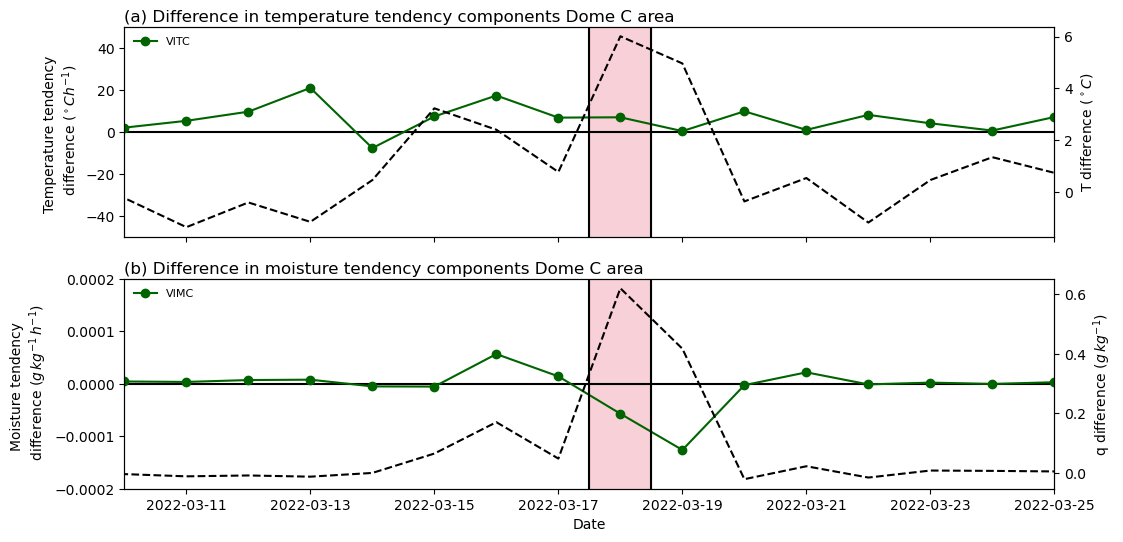

In [29]:
fig, (ax1, ax2)  = plt.subplots(2, 1, sharey=False, sharex=True, gridspec_kw={'hspace': 0.2, 'wspace':0.3}, figsize=(12,6), facecolor='white')

ax1b = ax1.twinx()
ax2b = ax2.twinx()

#Concordia Temp
ax1.plot([times[0],times[-1]],[0,0], 'k-')
ax1.plot(times_D, VITC_hist_msk_D.mean(axis=(1,2)) - VITC_past_msk_D.mean(axis=(1,2)), 'o-', c='DarkGreen', label='VITC')

ax1.legend(ncol=2, loc='upper left', frameon=False, fontsize=8)

ax1b.plot(times_D, T_hist_msk_D.mean(axis=(1,2)) - T_past_msk_D.mean(axis=(1,2)), '--', color='k', label='T')

ax1.text(0, 1.01, '(a) Difference in temperature tendency components Dome C area', horizontalalignment='left', verticalalignment='bottom', transform=ax1.transAxes, fontsize=12)
ax1.legend(ncol=2, loc='upper left', frameon=False, fontsize=8)

#Concordia Q
ax2.plot([times[0],times[-1]],[0,0], 'k-')
ax2.plot(times_D, VIMC_hist_msk_D.mean(axis=(1,2)) - VIMC_past_msk_D.mean(axis=(1,2)), 'o-', c='DarkGreen', label='VIMC')

ax2b.plot(times_D, Q_hist_msk_D.mean(axis=(1,2)) - Q_past_msk_D.mean(axis=(1,2)), '--', color='k', label='Q')

ax2.text(0, 1.01, '(b) Difference in moisture tendency components Dome C area', horizontalalignment='left', verticalalignment='bottom', transform=ax2.transAxes, fontsize=12)
ax2.legend(ncol=2, loc='upper left', frameon=False, fontsize=8)

#Plot parameters
ax2.set_xlabel('Date')
ax1.set_ylabel('Temperature tendency \n difference ($^\circ C h^{-1}$)')
ax2.set_ylabel('Moisture tendency \n difference ($g\, kg^{-1}\, h^{-1}$)')
ax1b.set_ylabel('T difference ($^\circ C$)')
ax2b.set_ylabel('q difference ($g\, kg^{-1}$)')
ax1.set_xlim(times[tiniTS], times[tendTS])

ax1.set_ylim(-50, 50)
ax2.set_ylim(-0.0002, 0.0002)
#ax2.set_ylim(-25, 0)

ax1.fill_between([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-18T12')], -100, 100, color='Crimson', alpha=0.2, zorder=0)
ax2.fill_between([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-18T12')], -100, 100, color='Crimson', alpha=0.2, zorder=0)
ax1.plot([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-17T12')],[-100,100], 'k-')
ax1.plot([np.datetime64('2022-03-18T12'),np.datetime64('2022-03-18T12')],[-100,100], 'k-')
ax2.plot([np.datetime64('2022-03-17T12'),np.datetime64('2022-03-17T12')],[-100,100], 'k-')
ax2.plot([np.datetime64('2022-03-18T12'),np.datetime64('2022-03-18T12')],[-100,100], 'k-')

plt.savefig('Figure_DriversVIMD_DomeC_Change.png', dpi=300, bbox_inches = 'tight')

[]

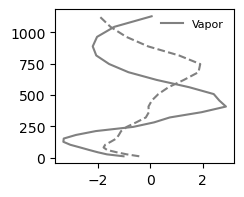

In [30]:
#Positions
CON_xy = wrf.ll_to_xy(wrflist_oh, -75.09978, 123.332196) #Concordia
CON_ll = wrf.xy_to_ll(wrflist_oh, CON_xy[0], CON_xy[1])

#Times mean
tini = np.where(times == np.datetime64('2022-03-17T00'))[0][0]
tend = np.where(times == np.datetime64('2022-03-20T00'))[0][0]

#Times Timeseries
tiniTS = np.where(times == np.datetime64('2022-03-10T00'))[0][0]
tendTS = np.where(times == np.datetime64('2022-03-25T00'))[0][0]

####################
### Plot DRIVERS ###
#Figure and axis
fig = plt.figure(figsize=[18,8])
spec = gridspec.GridSpec(ncols=5, nrows=3, figure=fig, hspace= 0.5, wspace=0.7)

#Concordia absolute values q profile
#ax2b = ax2.twiny()
ax2 = fig.add_subplot(spec[0, 1])
ax2.plot(wrf.to_np(MC_hist[tini:tend,:,CON_xy[1],CON_xy[0]].mean(axis=0))*1000, Z_ant_hist_unstg[0,:26,CON_xy[1],CON_xy[0]] - height[CON_xy[1],CON_xy[0]].values, c='Grey', label='Vapor')
ax2.plot(wrf.to_np(MC_past[tini:tend,:,CON_xy[1],CON_xy[0]].mean(axis=0))*1000, Z_ant_hist_unstg[0,:26,CON_xy[1],CON_xy[0]] - height[CON_xy[1],CON_xy[0]].values, '--', c='Grey')
ax2.legend(frameon=False, fontsize=8)

plt.plot()

In [31]:
from scipy import stats

#Function estimate mean difference with error bars
def mean_diff_with_error(x_hist, x_past, conf=0.95):
    x_hist = np.asarray(x_hist)
    x_past = np.asarray(x_past)
    mx, my = np.mean(x_hist), np.mean(x_past)
    vx, vy = np.var(x_hist, ddof=1), np.var(x_past, ddof=1)
    nx, ny = len(x_hist), len(x_past)
    # Mean difference
    diff = mx - my
    # Standard error (Welch)
    se = np.sqrt(vx/nx + vy/ny)
    # Welch–Satterthwaite degrees of freedom
    df = (vx/nx + vy/ny)**2 / ((vx/nx)**2/(nx-1) + (vy/ny)**2/(ny-1))
    # Critical t value
    tcrit = stats.t.ppf(1 - (1-conf)/2, df)
    # ± error
    err = tcrit * se
    return diff, err

print('Tendency Components Differences (Past - Hist) at Concordia during Heatwave Build-up Period')
print(stats.ttest_ind(Adv_past_dist_build, Adv_hist_dist_build, equal_var=False))
print(stats.ttest_ind(VAdv_past_dist_build, VAdv_hist_dist_build, equal_var=False))
print(stats.ttest_ind(Res_past_dist_build, Res_hist_dist_build, equal_var=False))
print(stats.ttest_ind(Tend_past_dist_build, Tend_hist_dist_build, equal_var=False))

print("Adv:",  mean_diff_with_error(Adv_hist_dist_build,  Adv_past_dist_build))
print("VAdv:", mean_diff_with_error(VAdv_hist_dist_build, VAdv_past_dist_build))
print("Res:",  mean_diff_with_error(Res_hist_dist_build,  Res_past_dist_build))
print("Tend:", mean_diff_with_error(Tend_hist_dist_build, Tend_past_dist_build))


print('-------------------------------------')

print('Tendency Components Differences (Past - Hist) of moisture at Concordia during Heatwave Build-up Period')
print(stats.ttest_ind(AdvQ_past_dist_build, AdvQ_hist_dist_build, equal_var=False))
print(stats.ttest_ind(VAdvQ_past_dist_build, VAdvQ_hist_dist_build, equal_var=False))
print(stats.ttest_ind(ResQ_past_dist_build, ResQ_hist_dist_build, equal_var=False))
print(stats.ttest_ind(TendQ_past_dist_build, TendQ_hist_dist_build, equal_var=False))  

print("AdvQ:",  mean_diff_with_error(AdvQ_hist_dist_build,  AdvQ_past_dist_build))
print("VAdvQ:", mean_diff_with_error(VAdvQ_hist_dist_build, VAdvQ_past_dist_build))
print("ResQ:",  mean_diff_with_error(ResQ_hist_dist_build,  ResQ_past_dist_build))
print("TendQ:", mean_diff_with_error(TendQ_hist_dist_build, TendQ_past_dist_build))


print('-------------------------------------')

print('VIMD and VITD (Past - Hist) at Concordia during Heatwave Build-up Period')
print(stats.ttest_ind(VIMC_hist_msk_D_dist_build, VIMC_past_msk_D_dist_build, equal_var=False))
print(stats.ttest_ind(VITC_hist_msk_D_dist_build, VITC_past_msk_D_dist_build, equal_var=False))

print("VIMC:",  mean_diff_with_error(VIMC_hist_msk_D_dist_build,  VIMC_past_msk_D_dist_build))
print("VITC:",  mean_diff_with_error(VITC_hist_msk_D_dist_build,  VITC_past_msk_D_dist_build))


Tendency Components Differences (Past - Hist) at Concordia during Heatwave Build-up Period
Ttest_indResult(statistic=-19.48588165775601, pvalue=5.364653644909573e-73)
Ttest_indResult(statistic=12.5778846683843, pvalue=1.3272771039583546e-33)
Ttest_indResult(statistic=-7.880578192565977, pvalue=9.17824108932949e-15)
Ttest_indResult(statistic=-21.7972565418932, pvalue=3.7302915517291706e-88)
Adv: (0.684164860885909, 0.06889078383676596)
VAdv: (-1.1890294813045073, 0.1855248977828838)
Res: (0.7226036241319775, 0.17995413526549192)
Tend: (0.21773900371337998, 0.01959971769697142)
-------------------------------------
Tendency Components Differences (Past - Hist) of moisture at Concordia during Heatwave Build-up Period
Ttest_indResult(statistic=-29.37004904920216, pvalue=1.9251672428705137e-142)
Ttest_indResult(statistic=7.201177376738487, pvalue=1.1166010969628831e-12)
Ttest_indResult(statistic=-0.08822049679481028, pvalue=0.929717041789122)
Ttest_indResult(statistic=-31.185141687469947, p

In [32]:
np.mean(Z_sig_hist[:,:,CON_xy[1]-1, CON_xy[0]-1], axis=0) - height[CON_xy[1]-1, CON_xy[0]-1].values

array([  10.712402,   26.228516,   43.26123 ,   61.956055,   82.458984,
        104.91943 ,  129.4851  ,  156.28955 ,  185.4624  ,  217.14429 ,
        251.48706 ,  288.64526 ,  328.7661  ,  371.97852 ,  418.4109  ,
        468.18555 ,  521.4092  ,  578.1675  ,  638.5481  ,  702.6323  ,
        770.5     ,  842.2339  ,  917.94116 ,  997.7761  , 1081.9714  ,
       1170.8723  ], dtype=float32)

/tmp/ipykernel_151856/4193284642.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')


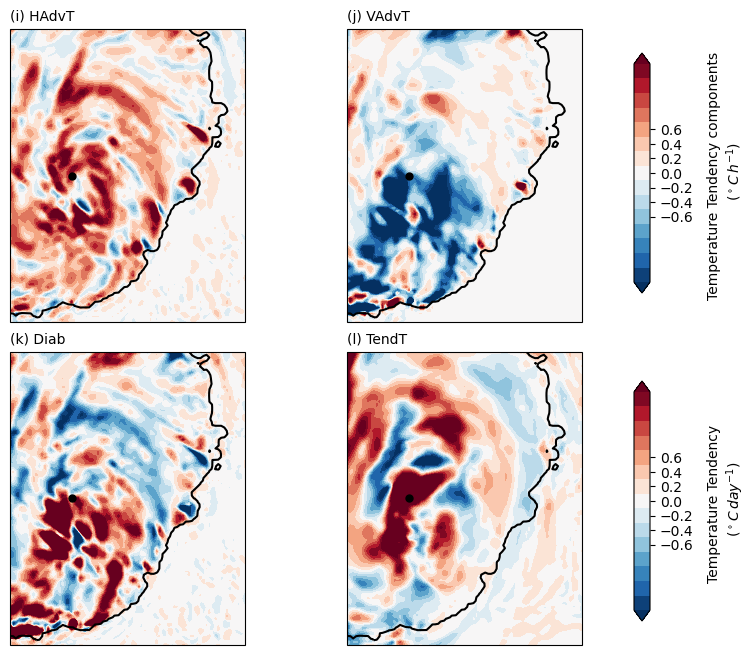

In [33]:
#############################################
# Plot Change in Temperature Tendency Equation components (level simga = 2)
#############################################

min_height = 10

time_ix_ini = np.where(times == np.datetime64('2022-03-18T00'))[0][0]
time_ix_end = np.where(times == np.datetime64('2022-03-19T00'))[0][0]
  
#################
### Plot Norm ###
#Figure and axis
fig = plt.figure(figsize=[8,8])
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=fig, hspace= 0.1, wspace=0.1)

### Background
ax1 = fig.add_subplot(spec[0, 0], projection=ccrs.SouthPolarStereo())
ax2 = fig.add_subplot(spec[0, 1], projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(spec[1, 0], projection=ccrs.SouthPolarStereo())
ax4 = fig.add_subplot(spec[1, 1], projection=ccrs.SouthPolarStereo())

CS1 = ax1.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS2 = ax2.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS3 = ax3.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS4 = ax4.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")

for ax in [ax1, ax2, ax3, ax4]:
    ax.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')
    #ax.plot(wrf.to_np(DDU_xy)[0], wrf.to_np(DDU_xy)[1], 'ko', markersize=5, color='k')
    #ax.plot(wrf.to_np(CIS_xy)[0], wrf.to_np(CIS_xy)[1], 'ko', markersize=5, color='k')

#Calculate difference between the beginning and the end of the event
Adv_hist_event = wrf.to_np(Adv_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(Adv_past[time_ix_ini:time_ix_end,:,:].mean(axis=0))
VAdv_hist_event = wrf.to_np(VAdv_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(VAdv_past[time_ix_ini:time_ix_end,:,:].mean(axis=0))
Res_hist_event = wrf.to_np(Res_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(Res_past[time_ix_ini:time_ix_end,:,:].mean(axis=0))
Tend_hist_event = wrf.to_np(Tend_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(Tend_past[time_ix_ini:time_ix_end,:,:].mean(axis=0))

fill1 = ax1.contourf(Adv_hist_event, np.arange(-1.5,1.51,0.2), cmap='RdBu_r', extend="both")
fill2 = ax2.contourf(VAdv_hist_event, np.arange(-1.5,1.51,0.2), cmap='RdBu_r', extend="both")
fill3 = ax3.contourf(Res_hist_event, np.arange(-1.5,1.51,0.2), cmap='RdBu_r', extend="both")
fill4 = ax4.contourf(Tend_hist_event*8, np.arange(-1.5,1.51,0.2), cmap='RdBu_r', extend="both")

ax1.set_title('(i) HAdvT', loc='left', fontsize=10)
ax2.set_title('(j) VAdvT', loc='left', fontsize=10)
ax3.set_title('(k) Diab', loc='left', fontsize=10)
ax4.set_title('(l) TendT', loc='left', fontsize=10)

fig.subplots_adjust(right=0.93)
cbar_ax_1 = fig.add_axes([0.95, 0.55, 0.02, 0.3])
cbar_1 = fig.colorbar(fill1, cax=cbar_ax_1, orientation = 'vertical', shrink=0.5, pad=0)
cbar_1.set_label('Temperature Tendency components \n ($^\circ C\, h^{-1}$)', labelpad=10)
cbar_1.set_ticks(np.arange(-0.6,0.61,0.2))

cbar_ax_2 = fig.add_axes([0.95, 0.14, 0.02, 0.3])
cbar_2 = fig.colorbar(fill4, cax=cbar_ax_2, orientation = 'vertical', shrink=0.5, pad=0)
cbar_2.set_label('Temperature Tendency \n ($^\circ C\, day^{-1}$)', labelpad=10)
cbar_2.set_ticks(np.arange(-0.6,0.61,0.2))


for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent([140, 220, 30, 130], crs=ccrs.SouthPolarStereo())
    ax.contourf(np.where(np.isnan(Res_hist_event), 1, 0), [0.1, 1000], cmap='Greys')

/tmp/ipykernel_151856/3227487140.py:28: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko" (-> color='k'). The keyword argument will take precedence.
  ax.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')


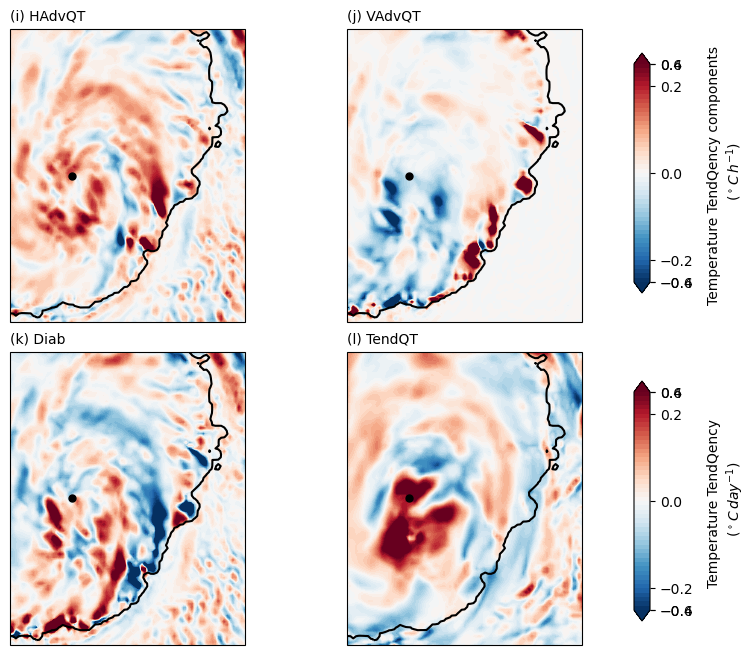

In [34]:
#############################################
# Plot Change in Temperature TendQency Equation components (level simga = 2)
#############################################

min_height = 10

time_ix_ini = np.where(times == np.datetime64('2022-03-18T00'))[0][0]
time_ix_end = np.where(times == np.datetime64('2022-03-19T00'))[0][0]
  
#################
### Plot Norm ###
#Figure and axis
fig = plt.figure(figsize=[8,8])
spec = gridspec.GridSpec(ncols=2, nrows=2, figure=fig, hspace= 0.1, wspace=0.1)

### Background
ax1 = fig.add_subplot(spec[0, 0], projection=ccrs.SouthPolarStereo())
ax2 = fig.add_subplot(spec[0, 1], projection=ccrs.SouthPolarStereo())
ax3 = fig.add_subplot(spec[1, 0], projection=ccrs.SouthPolarStereo())
ax4 = fig.add_subplot(spec[1, 1], projection=ccrs.SouthPolarStereo())

CS1 = ax1.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS2 = ax2.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS3 = ax3.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")
CS4 = ax4.contour(wrf.to_np(height), np.arange(10,9000,8000), cmap="gray", extend="both")

for ax in [ax1, ax2, ax3, ax4]:
    ax.plot(wrf.to_np(CON_xy)[0], wrf.to_np(CON_xy)[1], 'ko', markersize=5, color='k')
    #ax.plot(wrf.to_np(DDU_xy)[0], wrf.to_np(DDU_xy)[1], 'ko', markersize=5, color='k')
    #ax.plot(wrf.to_np(CIS_xy)[0], wrf.to_np(CIS_xy)[1], 'ko', markersize=5, color='k')

#Calculate difference between the beginning and the end of the event
AdvQ_hist_event = wrf.to_np(AdvQ_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(AdvQ_past[time_ix_ini:time_ix_end,:,:].mean(axis=0))
VAdvQ_hist_event = wrf.to_np(VAdvQ_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(VAdvQ_past[time_ix_ini:time_ix_end,:,:].mean(axis=0))
ResQ_hist_event = wrf.to_np(ResQ_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(ResQ_past[time_ix_ini:time_ix_end,:,:].mean(axis=0))
TendQ_hist_event = wrf.to_np(TendQ_hist[time_ix_ini:time_ix_end,:,:].mean(axis=0)) - wrf.to_np(TendQ_past[time_ix_ini:time_ix_end,:,:].mean(axis=0))

fill1 = ax1.contourf(AdvQ_hist_event, np.arange(-.25,.26,0.01), cmap='RdBu_r', extend="both")
fill2 = ax2.contourf(VAdvQ_hist_event, np.arange(-.25,.26,0.01), cmap='RdBu_r', extend="both")
fill3 = ax3.contourf(ResQ_hist_event, np.arange(-.25,.26,0.01), cmap='RdBu_r', extend="both")
fill4 = ax4.contourf(TendQ_hist_event*8, np.arange(-.25,.26,0.01), cmap='RdBu_r', extend="both")

ax1.set_title('(i) HAdvQT', loc='left', fontsize=10)
ax2.set_title('(j) VAdvQT', loc='left', fontsize=10)
ax3.set_title('(k) Diab', loc='left', fontsize=10)
ax4.set_title('(l) TendQT', loc='left', fontsize=10)

fig.subplots_adjust(right=0.93)
cbar_ax_1 = fig.add_axes([0.95, 0.55, 0.02, 0.3])
cbar_1 = fig.colorbar(fill1, cax=cbar_ax_1, orientation = 'vertical', shrink=0.5, pad=0)
cbar_1.set_label('Temperature TendQency components \n ($^\circ C\, h^{-1}$)', labelpad=10)
cbar_1.set_ticks(np.arange(-0.6,0.61,0.2))

cbar_ax_2 = fig.add_axes([0.95, 0.14, 0.02, 0.3])
cbar_2 = fig.colorbar(fill4, cax=cbar_ax_2, orientation = 'vertical', shrink=0.5, pad=0)
cbar_2.set_label('Temperature TendQency \n ($^\circ C\, day^{-1}$)', labelpad=10)
cbar_2.set_ticks(np.arange(-0.6,0.61,0.2))


for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent([140, 220, 30, 130], crs=ccrs.SouthPolarStereo())
    ax.contourf(np.where(np.isnan(ResQ_hist_event), 1, 0), [0.1, 1000], cmap='Greys')